Dans ce fichier on fera la préparation sur le fichier général et analyser les variables constantes

#### importation et chargement des données 

In [1]:
import pandas as pd
import numpy as np

# Chargement du fichier
general_data = pd.read_csv("data/general_data.csv")

# Affichage des premières lignes
general_data.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,...,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,1,Female,...,1.0,Y,11,8,0,1.0,6,1,0,0
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,2,Female,...,0.0,Y,23,8,1,6.0,3,5,1,4
2,32,No,Travel_Frequently,Research & Development,17,4,Other,1,3,Male,...,1.0,Y,15,8,3,5.0,2,5,0,3
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,1,4,Male,...,3.0,Y,11,8,3,13.0,5,8,7,5
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,5,Male,...,4.0,Y,12,8,2,9.0,2,6,0,4


#### verification des informations générales

In [5]:
# Infos sur le dataset
general_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   object 
 2   BusinessTravel           4410 non-null   object 
 3   Department               4410 non-null   object 
 4   DistanceFromHome         4410 non-null   int64  
 5   Education                4410 non-null   int64  
 6   EducationField           4410 non-null   object 
 7   EmployeeCount            4410 non-null   int64  
 8   EmployeeID               4410 non-null   int64  
 9   Gender                   4410 non-null   object 
 10  JobLevel                 4410 non-null   int64  
 11  JobRole                  4410 non-null   object 
 12  MaritalStatus            4410 non-null   object 
 13  MonthlyIncome            4410 non-null   int64  
 14  NumCompaniesWorked      

##### commentaire sur ces informations 
Le dataset contient 4410 lignes, soit 4410 employés.

24 colonnes correspondant aux variables RH.

Index automatique allant de 0 à 4409.

**Types de variables**

**14** variables numériques entières (int64)

**2** variables numériques continues (float64)

**8** variables catégorielles (object)

Le dataset est mixte, ce qui est classique pour des données RH : certaines variables sont quantitatives (salaire, ancienneté…), d’autres qualitatives (sexe, département, métier…).



**verification des valeurs manquantes**

| Variable                | Non-null count     |
| ----------------------- | ------------------ |
| NumCompaniesWorked      | 4391               |
| TotalWorkingYears       | 4401               |
| Toutes les autres       | 4410               |

il y'a donc **19 valeurs manquantes** dans la colonne NumCompaniesWorked,
**9 valeurs manquantes** dans la colonne TotalWorkingyears

In [6]:
# Statistiques descriptives pour les variables numériques
general_data.describe()

,Age,DistanceFromHome,Education,EmployeeCount,EmployeeID,JobLevel,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
count,4410.000000,4410.000000,4410.000000,4410.0,4410.000000,4410.000000,4410.000000,4391.000000,4410.000000,4410.0,4410.000000,4401.000000,4410.000000,4410.000000,4410.000000,4410.000000
mean,36.923810,9.192517,2.912925,1.0,2205.500000,2.063946,65029.312925,2.694830,15.209524,8.0,0.793878,11.279936,2.799320,7.008163,2.187755,4.123129
std,9.133301,8.105026,1.023933,0.0,1273.201673,1.106689,47068.888559,2.498887,3.659108,0.0,0.851883,7.782222,1.288978,6.125135,3.221699,3.567327
min,18.000000,1.000000,1.000000,1.0,1.000000,1.000000,10090.000000,0.000000,11.000000,8.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,2.000000,2.000000,1.0,1103.250000,1.000000,29110.000000,1.000000,12.000000,8.0,0.000000,6.000000,2.000000,3.000000,0.000000,2.000000
50%,36.000000,7.000000,3.000000,1.0,2205.500000,2.000000,49190.000000,2.000000,14.000000,8.0,1.000000,10.000000,3.000000,5.000000,1.000000,3.000000
75%,43.000000,14.000000,4.000000,1.0,3307.750000,3.000000,83800.000000,4.000000,18.000000,8.0,1.000000,15.000000,3.000000,9.000000,3.000000,7.000000
max,60.000000,29.000000,5.000000,1.0,4410.000000,5.000000,199990.000000,9.000000,25.000000,8.0,3.000000,40.000000,6.000000,40.000000,15.000000,17.000000


#### identification et analyse des constantes

Une **variable constante** est une colonne dont toutes les valeurs sont identiques. Ces variables n’apportent aucune information pour la modélisation et peuvent être supprimées.

In [7]:
# Liste des colonnes constantes
constant_columns = [col for col in general_data.columns if general_data[col].nunique() == 1]

print("Colonnes constantes : ", constant_columns)

Colonnes constantes :  ['EmployeeCount', 'Over18', 'StandardHours']


nous allons supprimer ces colonnes car elles n'auront aucun impact sur la prédiction 

In [8]:
#general_data.drop(columns=constant_columns, inplace=True)


In [13]:
general_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   object 
 2   BusinessTravel           4410 non-null   object 
 3   Department               4410 non-null   object 
 4   DistanceFromHome         4410 non-null   int64  
 5   Education                4410 non-null   int64  
 6   EducationField           4410 non-null   object 
 7   EmployeeCount            4410 non-null   int64  
 8   EmployeeID               4410 non-null   int64  
 9   Gender                   4410 non-null   object 
 10  JobLevel                 4410 non-null   int64  
 11  JobRole                  4410 non-null   object 
 12  MaritalStatus            4410 non-null   object 
 13  MonthlyIncome            4410 non-null   int64  
 14  NumCompaniesWorked      

**visualition des variables catégorielles**

In [10]:
categorical_cols = general_data.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(general_data[col].value_counts())


--- Attrition ---
Attrition
No     3699
Yes     711
Name: count, dtype: int64

--- BusinessTravel ---
BusinessTravel
Travel_Rarely        3129
Travel_Frequently     831
Non-Travel            450
Name: count, dtype: int64

--- Department ---
Department
Research & Development    2883
Sales                     1338
Human Resources            189
Name: count, dtype: int64

--- EducationField ---
EducationField
Life Sciences       1818
Medical             1392
Marketing            477
Technical Degree     396
Other                246
Human Resources       81
Name: count, dtype: int64

--- Gender ---
Gender
Male      2646
Female    1764
Name: count, dtype: int64

--- JobRole ---
JobRole
Sales Executive              978
Research Scientist           876
Laboratory Technician        777
Manufacturing Director       435
Healthcare Representative    393
Manager                      306
Sales Representative         249
Research Director            240
Human Resources              156
Name: count,

**visualition des valeurs manquantes** 

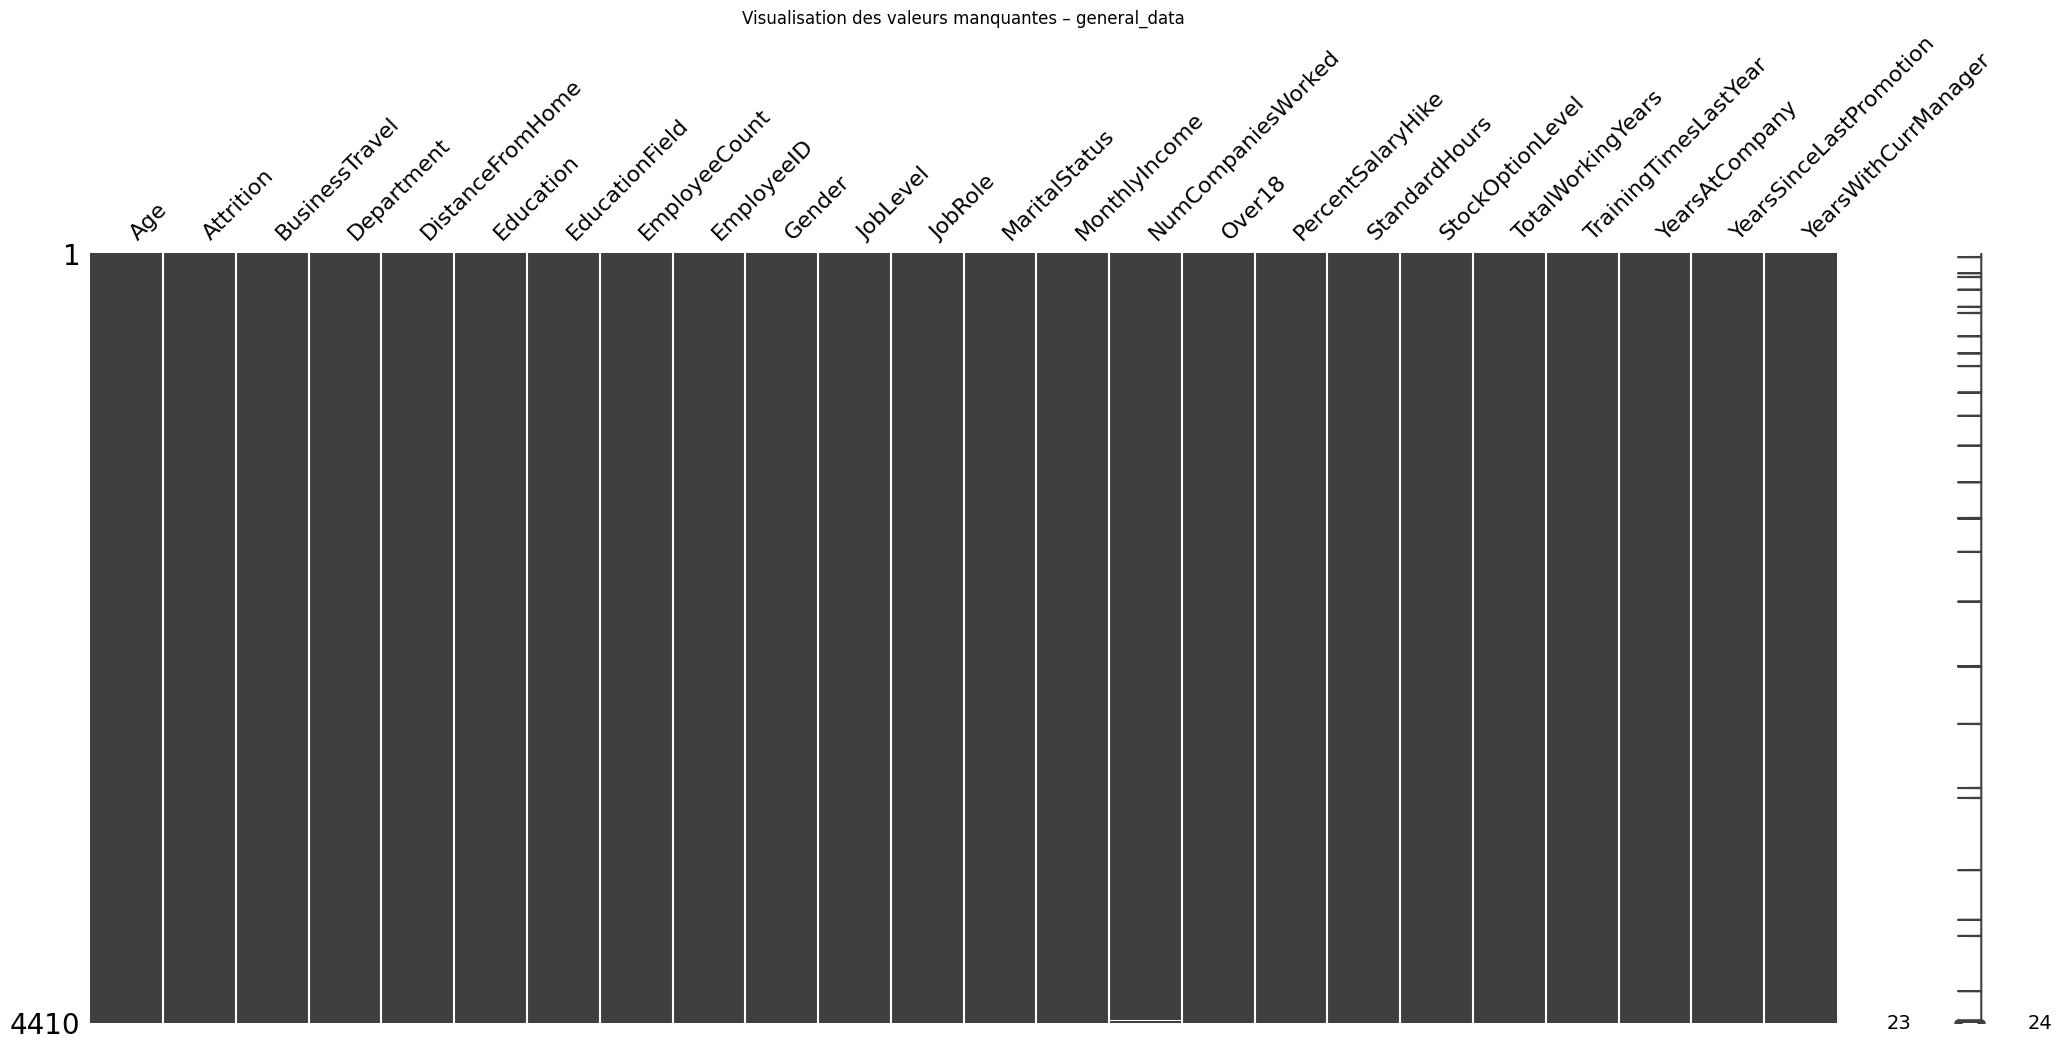

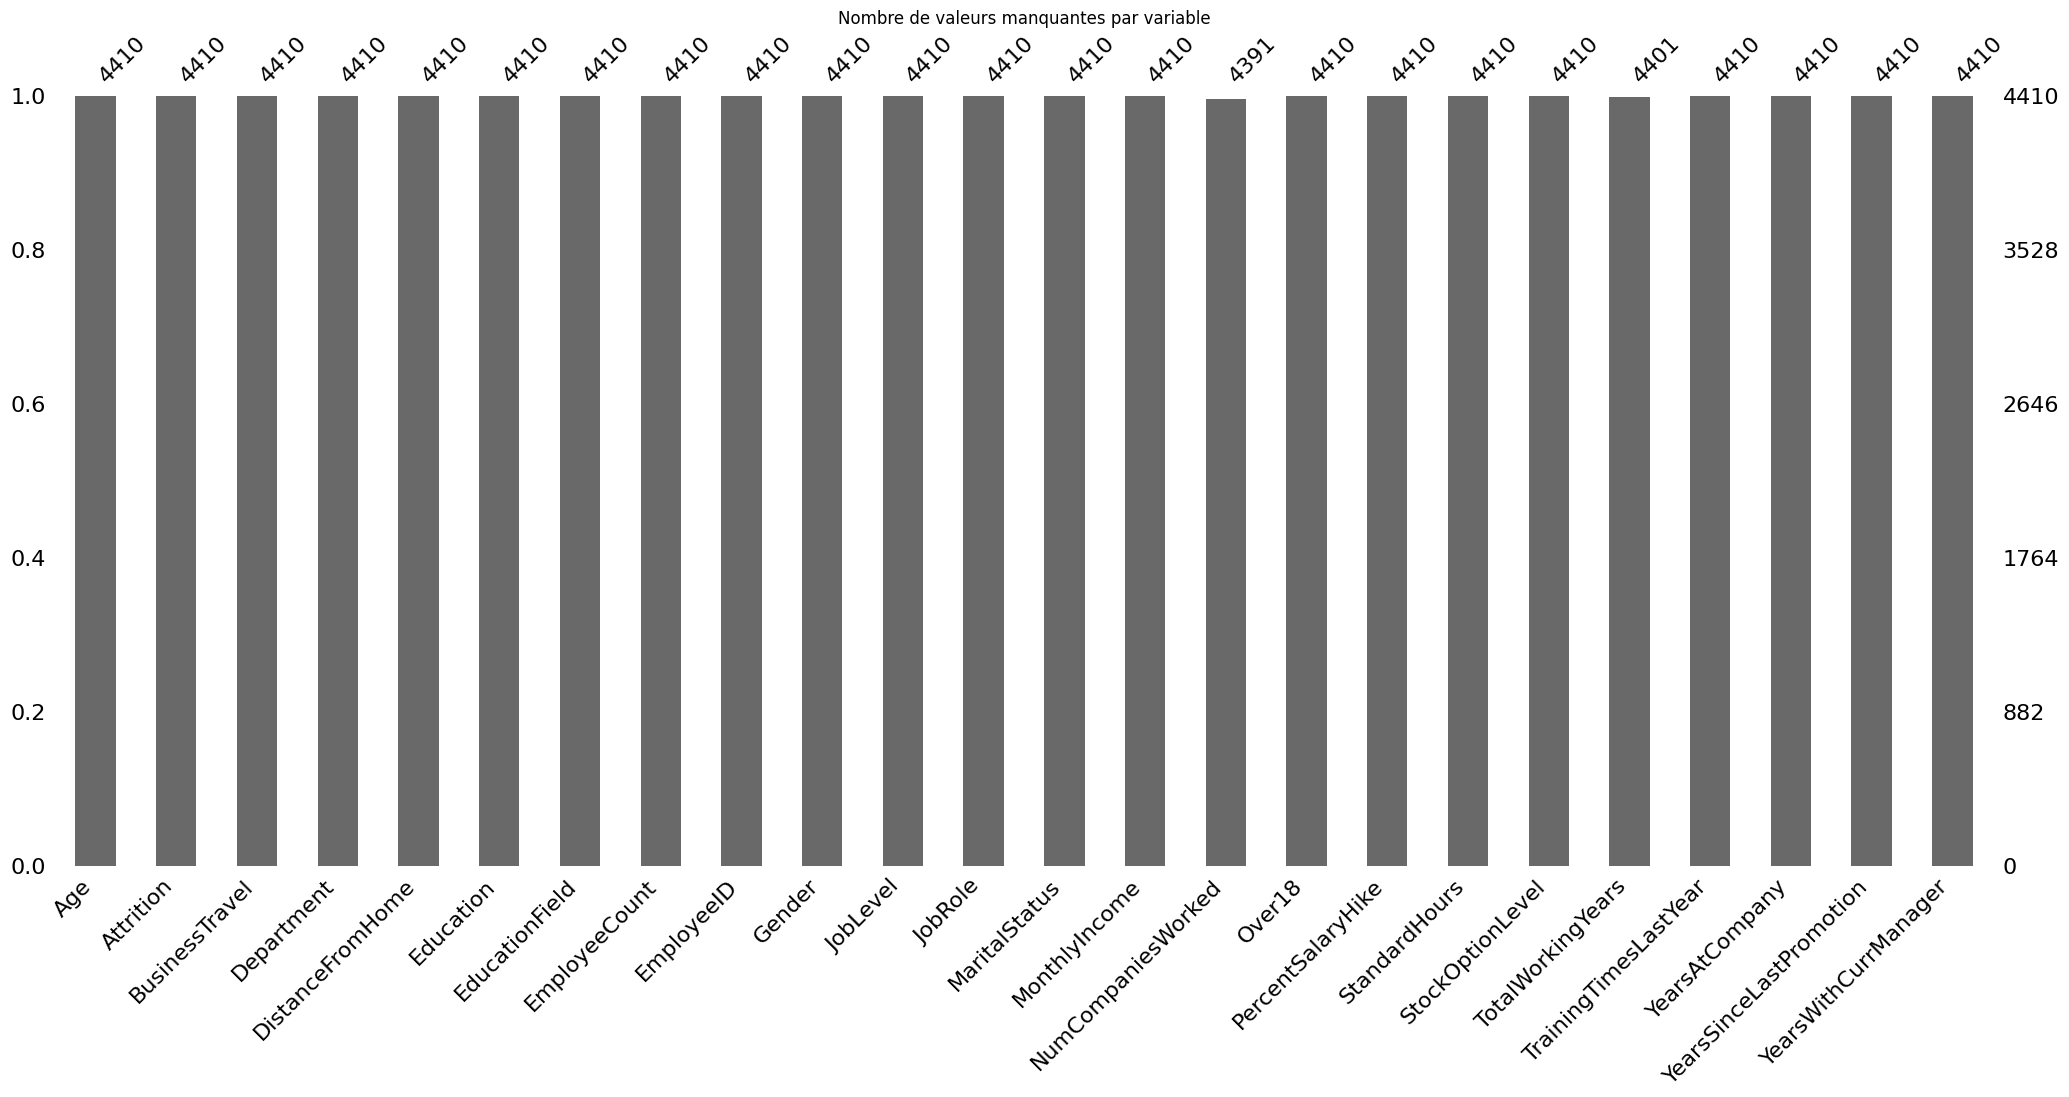

In [12]:
import matplotlib.pyplot as plt
import missingno as msno
# Afficher la matrice des valeurs manquantes
msno.matrix(general_data)
plt.title("Visualisation des valeurs manquantes – general_data")
plt.show()

# Afficher le barplot des valeurs manquantes
msno.bar(general_data)
plt.title("Nombre de valeurs manquantes par variable")
plt.show()

In [14]:
general_data.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeID                  0
Gender                      0
JobLevel                    0
JobRole                     0
MaritalStatus               0
MonthlyIncome               0
NumCompaniesWorked         19
Over18                      0
PercentSalaryHike           0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           9
TrainingTimesLastYear       0
YearsAtCompany              0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

**Remplissage des valeurs manquantes**

In [15]:
# Colonnes avec valeurs manquantes
missing_cols = ["NumCompaniesWorked", "TotalWorkingYears"]

for col in missing_cols:
    median_value = general_data[col].median()
    general_data[col].fillna(median_value, inplace=True)


C:\Users\HP\AppData\Local\Temp\ipykernel_13660\1431535464.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  general_data[col].fillna(median_value, inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_13660\1431535464.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

In [16]:
# Vérification qu'il ne reste plus de valeurs manquantes
general_data.isnull().sum()


Age                        0
Attrition                  0
BusinessTravel             0
Department                 0
DistanceFromHome           0
Education                  0
EducationField             0
EmployeeCount              0
EmployeeID                 0
Gender                     0
JobLevel                   0
JobRole                    0
MaritalStatus              0
MonthlyIncome              0
NumCompaniesWorked         0
Over18                     0
PercentSalaryHike          0
StandardHours              0
StockOptionLevel           0
TotalWorkingYears          0
TrainingTimesLastYear      0
YearsAtCompany             0
YearsSinceLastPromotion    0
YearsWithCurrManager       0
dtype: int64